Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Outputs:
 [0 1 1 0]


/Users/vemula/myenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training MLP for XOR ---
Training Completed!

XOR Accuracy: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Predictions:
Input: [0. 0.] → Output: 0.5342
Input: [0. 1.] → Output: 0.6192
Input: [1. 0.] → Output: 0.4578
Input: [1. 1.] → Output: 0.3947

Final Binary Output:
Input: [0. 0.] → Predicted: 1
Input: [0. 1.] → Predicted: 1
Input: [1. 0.] → Predicted: 0
Input: [1. 1.] → Predicted: 0


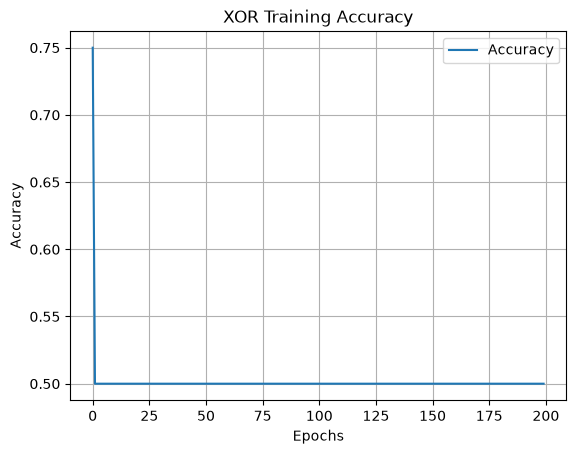

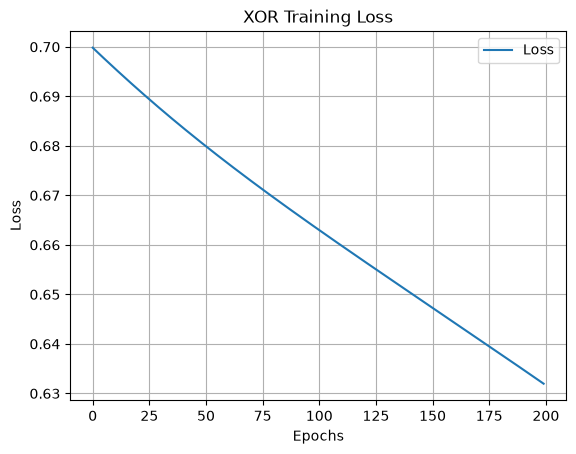

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 0])

print("Inputs:\n", X)
print("Outputs:\n", y)

mlp_model = models.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),  
    layers.Dense(1, activation='sigmoid')                  
])

mlp_model.summary()
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("\n--- Training MLP for XOR ---")

history = mlp_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("Training Completed!")

loss, acc = mlp_model.evaluate(X, y, verbose=0)
print(f"\nXOR Accuracy: {acc * 100:.2f}%")
predictions = mlp_model.predict(X)

print("\nPredictions:")
for i in range(len(X)):
    print(f"Input: {X[i]} → Output: {predictions[i][0]:.4f}")

# Convert probabilities to 0/1
final_preds = (predictions > 0.5).astype(int)

print("\nFinal Binary Output:")
for i in range(len(X)):
    print(f"Input: {X[i]} → Predicted: {final_preds[i][0]}")

plt.figure()

plt.plot(history.history['accuracy'], label='Accuracy')
plt.title("XOR Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()
plt.figure()

plt.plot(history.history['loss'], label='Loss')
plt.title("XOR Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()